# Visualizar un objeto Euclid Q1 a partir de `object_id` usando Astroquery

Este notebook consulta el archivo público de Euclid Q1 con `astroquery.esa.euclid`, localiza un objeto por `object_id`, obtiene sus coordenadas desde `catalogue.mer_catalogue`, busca el mosaico MER/VIS que cubre esa posición y descarga un cutout FITS para visualizarlo.

Objeto de ejemplo:

```python
object_id = 2686872296674105661
```

Referencias:

- Documentación `astroquery.esa.euclid`: https://astroquery.readthedocs.io/en/latest/esa/euclid/euclid.html
- El método `get_cutout` descarga pequeños cutouts de mosaicos MER background-subtracted; según la documentación actual, solo recupera cutouts desde mosaicos MER.


## 1. Instalación de dependencias

In [1]:
!pip -q install "astroquery>=0.4.11" astropy matplotlib numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.1 MB/s eta 0:00:00


## 2. Imports y configuración inicial

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.visualization import ImageNormalize, PercentileInterval, AsinhStretch

from astroquery.esa.euclid import Euclid, conf

Euclid.ROW_LIMIT = -1

OUTPUT_DIR = Path("euclid_object_cutouts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Euclid environment: PDR / public Q1")
try:
    print("Euclid TAP base URL:", conf.ENVIRONMENTS["PDR"]["url_server"])
except Exception:
    print("No se pudo imprimir conf.ENVIRONMENTS['PDR']['url_server']; no es crítico.")

Euclid environment: PDR / public Q1
Euclid TAP base URL: https://eas.esac.esa.int/


## 3. Parámetros del objeto

In [3]:
OBJECT_ID = 2686872296674105661
CUTOUT_RADIUS = 0.20 * u.arcmin  # prueba 0.10, 0.20, 0.50 arcmin según el tamaño deseado
INSTRUMENT_NAME = "VIS"          # normalmente VIS para imagen morfológica/cutout óptico

print("OBJECT_ID:", OBJECT_ID)
print("CUTOUT_RADIUS:", CUTOUT_RADIUS)
print("INSTRUMENT_NAME:", INSTRUMENT_NAME)

OBJECT_ID: 2686872296674105661
CUTOUT_RADIUS: 0.2 arcmin
INSTRUMENT_NAME: VIS


## 4. Consultar el objeto en `catalogue.mer_catalogue`

Primero buscamos el objeto por `object_id` en el catálogo MER. Necesitamos principalmente:

- `object_id`
- `right_ascension`
- `declination`
- algunas variables morfológicas/fotométricas útiles para inspección

Si la query no devuelve filas, el objeto no está disponible en el entorno público Q1 o el identificador no corresponde a `catalogue.mer_catalogue`.

In [4]:
mer_table = "catalogue.mer_catalogue"

query_object = f"""
SELECT
    object_id,
    right_ascension,
    declination,
    segmentation_area,
    ellipticity,
    kron_radius,
    flux_detection_total,
    flux_vis_sersic,
    vis_det,
    det_quality_flag
FROM {mer_table}
WHERE object_id = {OBJECT_ID}
"""

print(query_object)

job = Euclid.launch_job(query_object)
obj_table = job.get_results()

print("Rows returned:", len(obj_table))
obj_table


SELECT
    object_id,
    right_ascension,
    declination,
    segmentation_area,
    ellipticity,
    kron_radius,
    flux_detection_total,
    flux_vis_sersic,
    vis_det,
    det_quality_flag
FROM catalogue.mer_catalogue
WHERE object_id = 2686872296674105661

Rows returned: 1


object_id,right_ascension,declination,segmentation_area,ellipticity,kron_radius,flux_detection_total,flux_vis_sersic,vis_det,det_quality_flag
int64,float64,float64,int64,float64,float64,float64,float64,int64,int64
2686872296674105661,268.6872296746303,67.41056617129001,12188,0.08836761116981506,154.03750610351562,174.44989013671875,124.42298889160156,1,2


In [5]:
if len(obj_table) == 0:
    raise ValueError(
        f"No se encontró object_id={OBJECT_ID} en {mer_table}. "
        "Comprueba el ID o si pertenece a otro release/catálogo."
    )

obj = obj_table[0]
ra = float(obj["right_ascension"])
dec = float(obj["declination"])
coord = SkyCoord(ra=ra, dec=dec, unit=(u.deg, u.deg), frame="icrs")

print("RA:", ra)
print("Dec:", dec)
print("Coord:", coord.to_string("hmsdms"))

RA: 268.6872296746303
Dec: 67.41056617129001
Coord: 17h54m44.93512191s +67d24m38.03821664s


## 5. Buscar mosaicos MER/VIS que cubran la posición

Para descargar un cutout con `Euclid.get_cutout`, necesitamos localizar primero un producto de mosaico MER que cubra la coordenada del objeto. La documentación de Astroquery muestra esta búsqueda sobre `q1.mosaic_product` usando `INTERSECTS(CIRCLE(...), fov)=1`.

Usamos un radio pequeño en grados alrededor del objeto para exigir que el mosaico cubra la posición.

In [6]:
search_radius_deg = (0.5 * u.arcmin).to(u.deg).value

query_mosaics = f"""
SELECT
    file_name,
    file_path,
    datalabs_path,
    instrument_name,
    filter_name,
    ra,
    dec,
    creation_date,
    product_type,
    patch_id_list,
    tile_index
FROM q1.mosaic_product
WHERE instrument_name = '{INSTRUMENT_NAME}'
  AND INTERSECTS(CIRCLE({ra}, {dec}, {search_radius_deg}), fov) = 1
ORDER BY file_name
"""

print(query_mosaics)

mosaic_job = Euclid.launch_job_async(query_mosaics, verbose=False)
mosaics = mosaic_job.get_results()

print("Mosaics found:", len(mosaics))
mosaics


SELECT
    file_name,
    file_path,
    datalabs_path,
    instrument_name,
    filter_name,
    ra,
    dec,
    creation_date,
    product_type,
    patch_id_list,
    tile_index
FROM q1.mosaic_product
WHERE instrument_name = 'VIS'
  AND INTERSECTS(CIRCLE(268.6872296746303, 67.41056617129001, 0.008333333333333333), fov) = 1
ORDER BY file_name



INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
Mosaics found: 1


file_name,file_path,datalabs_path,instrument_name,filter_name,ra,dec,creation_date,product_type,patch_id_list,tile_index
str80,str51,str39,str3,str3,float64,float64,str23,str15,int64,int64
EUC_MER_BGSUB-MOSAIC-VIS_TILE102160058-D6A255_20241025T024641.423063Z_00.00.fits,/euclid/repository_idr/iqr1/Q1_R1/MER/102160058/VIS,/data/euclid_q1/Q1_R1/MER/102160058/VIS,VIS,VIS,268.7269899,67.5,2024-10-26T07:19:42.306,DpdMerBksMosaic,49,102160058


In [7]:
if len(mosaics) == 0:
    raise ValueError(
        "No se encontraron mosaicos MER/VIS cubriendo la posición. "
        "Prueba a aumentar search_radius_deg o revisa que el objeto esté en Q1."
    )

mosaic = mosaics[0]
file_name = str(mosaic["file_name"])
file_path = f"{mosaic['file_path']}/{mosaic['file_name']}"

print("Selected mosaic:")
print("tile_index:", mosaic["tile_index"])
print("instrument_name:", mosaic["instrument_name"])
print("filter_name:", mosaic["filter_name"])
print("file_name:", file_name)
print("file_path:", file_path)

Selected mosaic:
tile_index: 102160058
instrument_name: VIS
filter_name: VIS
file_name: EUC_MER_BGSUB-MOSAIC-VIS_TILE102160058-D6A255_20241025T024641.423063Z_00.00.fits
file_path: /euclid/repository_idr/iqr1/Q1_R1/MER/102160058/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102160058-D6A255_20241025T024641.423063Z_00.00.fits


## 6. Descargar cutout FITS del objeto

Esta celda descarga un cutout pequeño, no el mosaico completo. Según la documentación, `get_cutout` recupera cutouts desde mosaicos MER background-subtracted y acepta una coordenada `SkyCoord`, un `radius` y un `output_file`.

In [14]:
# ============================================================
# DOWNLOAD MER CUTOUT FOR OBJECT
# ============================================================

from pathlib import Path
import astropy.units as u
from astroquery.esa.euclid import Euclid

OUTPUT_DIR = Path("euclid_object_cutouts")
OUTPUT_DIR.mkdir(exist_ok=True)

object_id = 2686872296674105661

# file_path debe venir de q1.mosaic_product:
# file_path = f"{mosaic_res['file_path'][0]}/{mosaic_res['file_name'][0]}"

output_file = OUTPUT_DIR / f"euclid_object_{object_id}_cutout_MER_VIS.fits"

print("Downloading cutout to:", output_file)

cutout_paths = Euclid.get_cutout(
    file_path=file_path,
    instrument="VIS",
    id=str(object_id),
    coordinate=coord,
    radius=0.1 * u.arcmin,
    output_file=str(output_file),
    verbose=True,
)

cutout_path = cutout_paths[0]
print("Downloaded:", cutout_path)

Retrieving data.
Data request: TAPCLIENT=ASTROQUERY&FILEPATH=%2Feuclid%2Frepository_idr%2Fiqr1%2FQ1_R1%2FMER%2F102160058%2FVIS%2FEUC_MER_BGSUB-MOSAIC-VIS_TILE102160058-D6A255_20241025T024641.423063Z_00.00.fits&COLLECTION=VIS&OBSID=2686872296674105661&POS=CIRCLE%2C268.68722965718547%2C67.41057163970525%2C0.0016666666666666668
------>https
host = eas.esac.esa.int:443
context = /sas-cutout/cutout
Content-type = application/x-www-form-urlencoded
200 
Reading...
Done.
Downloaded: euclid_object_cutouts/euclid_object_2686872296674105661_cutout_MER_VIS.fits


## 7. Visualizar el cutout

Usamos una normalización robusta con intervalo percentil y stretch `asinh`, parecida a la que se recomienda en los ejemplos de Astroquery para imágenes Euclid.

FITS info:
Filename: euclid_object_cutouts/euclid_object_2686872296674105661_cutout_MER_VIS.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      49   (119, 119)   float32   
Image shape: (119, 119)


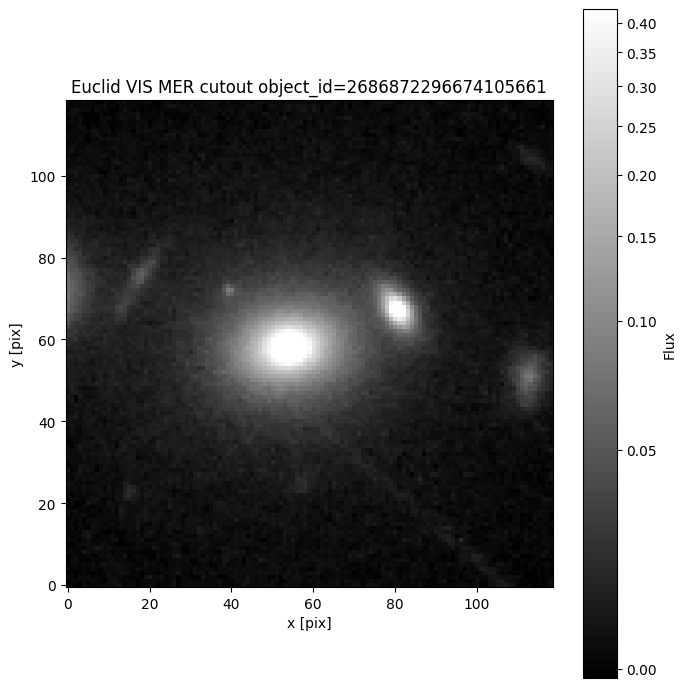

In [15]:
def load_first_image_hdu(fits_path):
    """Devuelve el primer HDU con datos de imagen 2D."""
    hdul = fits.open(fits_path)
    for hdu in hdul:
        data = hdu.data
        if data is not None and getattr(data, "ndim", 0) >= 2:
            while data.ndim > 2:
                data = data[0]
            return hdul, hdu, data
    hdul.close()
    raise ValueError("No se encontró ningún HDU con imagen 2D en el FITS.")

hdul, image_hdu, image_data = load_first_image_hdu(cutout_path)

print("FITS info:")
hdul.info()
print("Image shape:", image_data.shape)

plt.figure(figsize=(7, 7))
plt.imshow(
    image_data,
    cmap="gray",
    origin="lower",
    norm=ImageNormalize(
        image_data,
        interval=PercentileInterval(99.1),
        stretch=AsinhStretch(),
    ),
)
plt.colorbar(label="Flux")
plt.title(f"Euclid {INSTRUMENT_NAME} MER cutout object_id={OBJECT_ID}")
plt.xlabel("x [pix]")
plt.ylabel("y [pix]")
plt.tight_layout()
plt.show()

hdul.close()

## 8. Tabla resumen del objeto y producto usado

In [16]:
summary = pd.DataFrame([
    {
        "object_id": OBJECT_ID,
        "ra_deg": ra,
        "dec_deg": dec,
        "coord_hmsdms": coord.to_string("hmsdms"),
        "tile_index": str(mosaic["tile_index"]),
        "instrument_name": str(mosaic["instrument_name"]),
        "filter_name": str(mosaic["filter_name"]),
        "mosaic_file_name": file_name,
        "cutout_path": str(cutout_path),
    }
])

summary

,object_id,ra_deg,dec_deg,coord_hmsdms,tile_index,instrument_name,filter_name,mosaic_file_name,cutout_path
0,2686872296674105661,268.68723,67.410566,17h54m44.93512191s +67d24m38.03821664s,102160058,VIS,VIS,EUC_MER_BGSUB-MOSAIC-VIS_TILE102160058-D6A255_...,euclid_object_cutouts/euclid_object_2686872296...


## 9. Función reutilizable para otros `object_id`

Esta función encapsula todo el flujo anterior:

1. buscar objeto en `catalogue.mer_catalogue`
2. recuperar RA/Dec
3. buscar mosaico MER/VIS que cubre la posición
4. descargar cutout
5. mostrar imagen


In [24]:
def show_euclid_object_cutout(
    object_id,
    radius=0.1 * u.arcmin,
    instrument="VIS",
    output_dir="euclid_object_cutouts",
):
    from pathlib import Path

    import matplotlib.pyplot as plt
    import astropy.units as u

    from astropy.coordinates import SkyCoord
    from astropy.io import fits
    from astropy.visualization import ImageNormalize, PercentileInterval, AsinhStretch
    from astroquery.esa.euclid import Euclid

    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    object_id = str(object_id)

    # ------------------------------------------------------------
    # 1. Buscar objeto en el catálogo MER
    # ------------------------------------------------------------

    object_query = f"""
    SELECT *
    FROM catalogue.mer_catalogue
    WHERE object_id = {object_id}
    """

    job = Euclid.launch_job_async(object_query, verbose=False)
    result = job.get_results()

    if len(result) == 0:
        raise ValueError(f"Object_id {object_id} not found in catalogue.mer_catalogue")

    row = result[0]

    ra = float(row["right_ascension"])
    dec = float(row["declination"])

    coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)

    print(f"object_id: {object_id}")
    print(f"RA: {ra}")
    print(f"Dec: {dec}")

    # ------------------------------------------------------------
    # 2. Buscar mosaico MER/VIS que contiene el objeto
    # ------------------------------------------------------------

    radius_deg = radius.to(u.deg).value

    mosaic_query = f"""
    SELECT file_name, file_path, datalabs_path, instrument_name, filter_name,
           ra, dec, product_type, tile_index
    FROM q1.mosaic_product
    WHERE instrument_name = '{instrument}'
      AND INTERSECTS(
            CIRCLE({coord.ra.deg}, {coord.dec.deg}, {radius_deg}),
            fov
          ) = 1
    ORDER BY file_name
    """

    mosaic_job = Euclid.launch_job_async(mosaic_query, verbose=False)
    mosaic_result = mosaic_job.get_results()

    if len(mosaic_result) == 0:
        raise ValueError(f"No mosaic product found for object_id {object_id}")

    mosaic_row = mosaic_result[0]

    file_path = f"{mosaic_row['file_path']}/{mosaic_row['file_name']}"

    print("Using mosaic:")
    print(file_path)

    # ------------------------------------------------------------
    # 3. Descargar cutout
    # ------------------------------------------------------------

    output_file = output_dir / f"euclid_object_{object_id}_cutout_{instrument}.fits"

    cutout_paths = Euclid.get_cutout(
        file_path=file_path,
        instrument=instrument,
        id=object_id,
        coordinate=coord,
        radius=radius,
        output_file=str(output_file),
        verbose=True,
    )

    if isinstance(cutout_paths, list):
        cutout_path = cutout_paths[0]
    else:
        cutout_path = cutout_paths

    print("Downloaded:", cutout_path)

    # ------------------------------------------------------------
    # 4. Pintar imagen
    # ------------------------------------------------------------

    with fits.open(cutout_path) as hdul:
        image_data = hdul[0].data

    plt.figure(figsize=(7, 7))
    plt.imshow(
        image_data,
        cmap="gray",
        origin="lower",
        norm=ImageNormalize(
            image_data,
            interval=PercentileInterval(99.2),
            stretch=AsinhStretch(),
        ),
    )
    plt.title(f"Euclid {instrument} cutout\nobject_id={object_id}")
    plt.axis("off")
    plt.show()

    return {
        "object_id": object_id,
        "ra": ra,
        "dec": dec,
        "coord": coord,
        "file_path": file_path,
        "cutout_path": cutout_path,
        "object_row": row,
        "mosaic_row": mosaic_row,
    }

# Ejemplo:
# result = show_euclid_object_cutout(2686872296674105661)

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
object_id: 2686872296674105661
RA: 268.6872296746303
Dec: 67.41056617129001


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
Using mosaic:
/euclid/repository_idr/iqr1/Q1_R1/MER/102160058/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102160058-D6A255_20241025T024641.423063Z_00.00.fits
Retrieving data.
Data request: TAPCLIENT=ASTROQUERY&FILEPATH=%2Feuclid%2Frepository_idr%2Fiqr1%2FQ1_R1%2FMER%2F102160058%2FVIS%2FEUC_MER_BGSUB-MOSAIC-VIS_TILE102160058-D6A255_20241025T024641.423063Z_00.00.fits&COLLECTION=VIS&OBSID=2686872296674105661&POS=CIRCLE%2C268.68722965718547%2C67.41057163970525%2C0.002
------>https
host = eas.esac.esa.int:443
context = /sas-cutout/cutout
Content-type = application/x-www-form-urlencoded
200 
Reading...
Done.
Downloaded: euclid_object_cutouts/euclid_object_2686872296674105661_cutout_VIS.fits


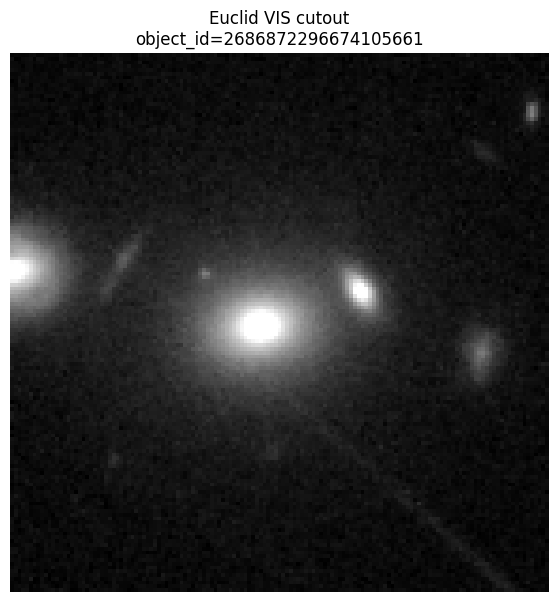

In [31]:
result1 = show_euclid_object_cutout(
    2686872296674105661,
    radius=0.12 * u.arcmin
)

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
object_id: 2745640369664151739
RA: 274.56403693147837
Dec: 66.41517397912139


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
Using mosaic:
/euclid/repository_idr/iqr1/Q1_R1/MER/102159490/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102159490-AC3333_20241025T022510.296091Z_00.00.fits
Retrieving data.
Data request: TAPCLIENT=ASTROQUERY&FILEPATH=%2Feuclid%2Frepository_idr%2Fiqr1%2FQ1_R1%2FMER%2F102159490%2FVIS%2FEUC_MER_BGSUB-MOSAIC-VIS_TILE102159490-AC3333_20241025T022510.296091Z_00.00.fits&COLLECTION=VIS&OBSID=2745640369664151739&POS=CIRCLE%2C274.56403852845045%2C66.41517969051436%2C0.0021666666666666666
------>https
host = eas.esac.esa.int:443
context = /sas-cutout/cutout
Content-type = application/x-www-form-urlencoded
200 
Reading...
Done.
Downloaded: euclid_object_cutouts/euclid_object_2745640369664151739_cutout_VIS.fits


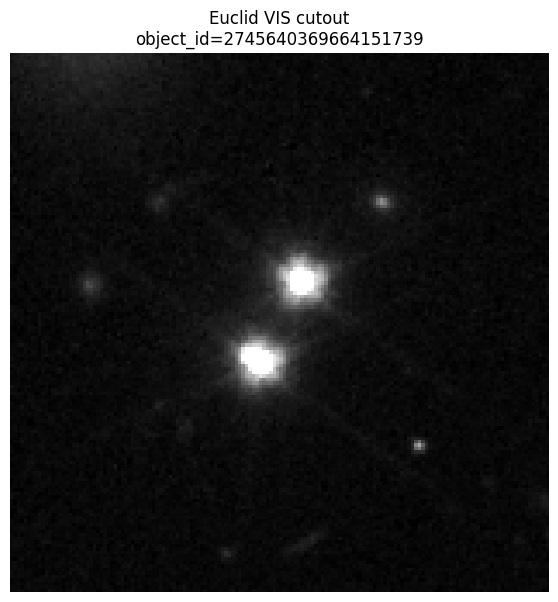

In [34]:

result2 = show_euclid_object_cutout(
    2745640369664151739,
    radius=0.13 * u.arcmin
)

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
object_id: -597793382466347816
RA: 59.779338274777125
Dec: -46.63478169062504


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
Using mosaic:
/euclid/repository_idr/iqr1/Q1_R1/MER/102022972/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102022972-641811_20241018T190010.248148Z_00.00.fits
Retrieving data.
Data request: TAPCLIENT=ASTROQUERY&FILEPATH=%2Feuclid%2Frepository_idr%2Fiqr1%2FQ1_R1%2FMER%2F102022972%2FVIS%2FEUC_MER_BGSUB-MOSAIC-VIS_TILE102022972-641811_20241018T190010.248148Z_00.00.fits&COLLECTION=VIS&OBSID=-597793382466347816&POS=CIRCLE%2C59.7793393775278%2C-46.63478519483099%2C0.0033333333333333335
------>https
host = eas.esac.esa.int:443
context = /sas-cutout/cutout
Content-type = application/x-www-form-urlencoded
200 
Reading...
Done.
Downloaded: euclid_object_cutouts/euclid_object_-597793382466347816_cutout_VIS.fits


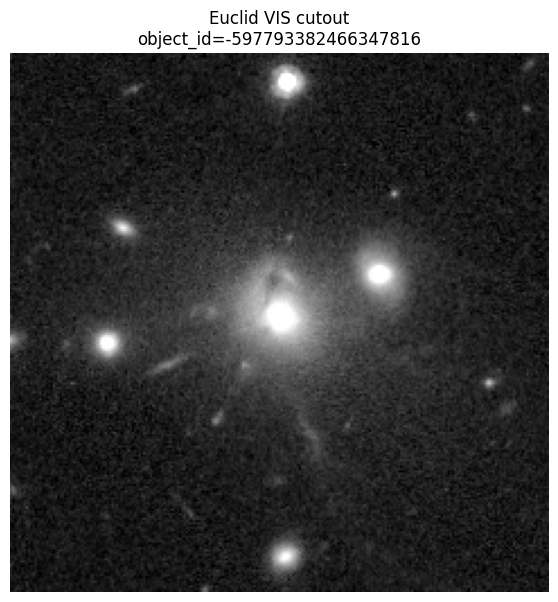

In [39]:
result3 = show_euclid_object_cutout(
    -597793382466347816,
    radius=0.2 * u.arcmin
)

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
object_id: -639706305497277844
RA: 63.97063058883589
Dec: -49.727784447975104


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
Using mosaic:
/euclid/repository_idr/iqr1/Q1_R1/MER/102020065/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102020065-9CF0D9_20241018T172335.526219Z_00.00.fits
Retrieving data.
Data request: TAPCLIENT=ASTROQUERY&FILEPATH=%2Feuclid%2Frepository_idr%2Fiqr1%2FQ1_R1%2FMER%2F102020065%2FVIS%2FEUC_MER_BGSUB-MOSAIC-VIS_TILE102020065-9CF0D9_20241018T172335.526219Z_00.00.fits&COLLECTION=VIS&OBSID=-639706305497277844&POS=CIRCLE%2C63.97063140581225%2C-49.7277883057971%2C0.0016666666666666668
------>https
host = eas.esac.esa.int:443
context = /sas-cutout/cutout
Content-type = application/x-www-form-urlencoded
200 
Reading...
Done.
Downloaded: euclid_object_cutouts/euclid_object_-639706305497277844_cutout_VIS.fits


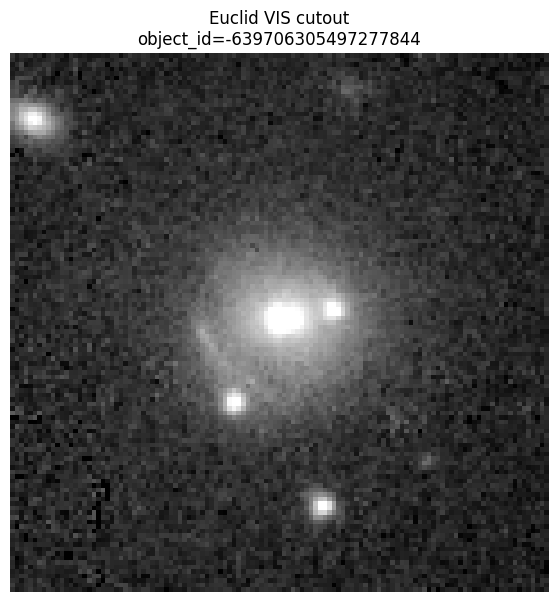

In [41]:
result4 = show_euclid_object_cutout(
    -639706305497277844,
    radius=0.1 * u.arcmin
)